# IGVF Perturb-seq Analysis

Analysis of CRISPRi perturb-seq data from the Huangfu lab (HUES8, definitive endoderm differentiation).

**Dataset:** `inference_mudata.h5mu` from Synapse (syn74822416)

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import mudata as md
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

md.set_options(pull_on_update=False)

DATA_PATH = "./data/inference_mudata.h5mu"

## 1. Load data and build ID mappings

In [2]:
mdata = md.read_h5mu(DATA_PATH)
print(mdata)
print(mdata.mod.keys())

MuData object with n_obs × n_vars = 269491 × 23735
  obs:	'batch'
  uns:	'cis_per_element_results', 'cis_per_guide_results', 'trans_per_element_results', 'trans_per_guide_results'
  2 modalities
    gene:	269491 × 9584
      obs:	'batch', 'batch_number', 'n_counts', 'log1p_n_genes_by_counts', 'total_gene_umis', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'percent_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
      var:	'symbol', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'gene_chr', 'gene_start', 'gene_end'
    guide:	269491 × 14151
      obs:	'batch', 'num_expressed_guides', 'total_guide_umis'
      var:	'guide_id', 'spacer', 'targeting', 'type', 'guide_chr', 'guide_start', 'guide_end', 'strand', 'pam', 'genomic_ele

In [3]:
# Ensembl ID -> gene symbol mapping (merging gene and guide sources)
gene_var = mdata.mod["gene"].var
guide_var = mdata.mod["guide"].var

id_to_symbol = gene_var["symbol"].to_dict()
id_to_symbol.update(
    guide_var[["intended_target_name", "gene_name"]]
    .drop_duplicates()
    .set_index("intended_target_name")["gene_name"]
    .to_dict()
)

In [4]:
gene_var

,symbol,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,gene_chr,gene_start,gene_end
gene_id,,,,,,,,,,,,,
ENSG00000230021,ENSG00000230021,False,False,184398,2.755162,1.323131,34.968313,781229.0,13.568624,184398,chr1,720024.0,720206.0
ENSG00000228794,LINC01128,False,False,15597,0.058508,0.056860,94.499402,16590.0,9.716616,15597,chr1,825138.0,859446.0
ENSG00000187634,SAMD11,False,False,70193,0.337826,0.291046,75.245018,95791.0,11.469934,70193,chr1,923923.0,944575.0
ENSG00000188976,NOC2L,False,False,24232,0.093436,0.089325,91.454095,26494.0,10.184711,24232,chr1,944203.0,959309.0
ENSG00000188290,HES4,False,False,37946,0.170784,0.157674,86.617575,48426.0,10.787813,37946,chr1,998962.0,1000172.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198786,MT-ND5,True,False,193018,4.787530,1.755706,31.928295,1357509.0,14.121162,193018,chrM,12337.0,14148.0
ENSG00000198695,MT-ND6,True,False,183077,2.816329,1.339289,35.434190,798573.0,13.590583,183077,chrM,14149.0,14673.0
ENSG00000198727,MT-CYB,True,False,203118,14.608878,2.747840,28.366326,4142362.0,15.236777,203118,chrM,14747.0,15887.0


In [5]:
guide_var

,guide_id,spacer,targeting,type,guide_chr,guide_start,guide_end,strand,pam,genomic_element,intended_target_name,intended_target_chr,intended_target_start,intended_target_end,putative_target_genes,reporter,imperfect,gene_name,intended_target_key
guide_id,,,,,,,,,,,,,,,,,,,
AARS#chr16:70289397-70289415(-),AARS#chr16:70289397-70289415(-),CCGCCCTCGGAGAGCTCTG,True,positive control,chr16,70289397.0,70289415.0,-,NGG,promoter,ENSG00000090861,chr16,70289397,70289415,NaN,NaN,NaN,AARS,coords::ENSG00000090861::chr16::70289397::7028...
AARS#chr16:70289419-70289437(-),AARS#chr16:70289419-70289437(-),CGGCGACCCTAGGAGAGGT,True,positive control,chr16,70289419.0,70289437.0,-,NGG,promoter,ENSG00000090861,chr16,70289409,70289495,NaN,NaN,NaN,AARS,coords::ENSG00000090861::chr16::70289409::7028...
AARS#chr16:70289477-70289495(-),AARS#chr16:70289477-70289495(-),TCTGCGGGAATAGGTGCAG,True,positive control,chr16,70289477.0,70289495.0,-,NGG,promoter,ENSG00000090861,chr16,70289409,70289495,NaN,NaN,NaN,AARS,coords::ENSG00000090861::chr16::70289409::7028...
B2M#chr15:44711560-44711578(-),B2M#chr15:44711560-44711578(-),GCGAGCACAGCTAAGGCCA,True,positive control,chr15,44711560.0,44711578.0,-,NGG,promoter,ENSG00000166710,chr15,44711545,44711959,NaN,NaN,NaN,B2M,coords::ENSG00000166710::chr15::44711545::4471...
CD151#chr11:833006-833024(+),CD151#chr11:833006-833024(+),CCGGACTCGGACGCGTGGT,True,positive control,chr11,833006.0,833024.0,+,NGG,promoter,ENSG00000177697,chr11,832818,833060,NaN,NaN,NaN,CD151,coords::ENSG00000177697::chr11::832818::833060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZZZ3#chr1:77682544-77682562(+),ZZZ3#chr1:77682544-77682562(+),ACCAAGAGGCACTCGCCCC,True,targeting,chr1,77682544.0,77682562.0,+,NGG,promoter,ENSG00000036549,chr1,77682531,77683403,NaN,NaN,NaN,ZZZ3,coords::ENSG00000036549::chr1::77682531::77683403
ZZZ3#chr1:77682717-77682735(+),ZZZ3#chr1:77682717-77682735(+),TCCACTAGACCCAACATGG,True,targeting,chr1,77682717.0,77682735.0,+,NGG,promoter,ENSG00000036549,chr1,77682531,77683403,NaN,NaN,NaN,ZZZ3,coords::ENSG00000036549::chr1::77682531::77683403
ZZZ3#chr1:77683038-77683056(-),ZZZ3#chr1:77683038-77683056(-),TGTGCGCGGGCGAAAGGGG,True,targeting,chr1,77683038.0,77683056.0,-,NGG,promoter,ENSG00000036549,chr1,77682531,77683403,NaN,NaN,NaN,ZZZ3,coords::ENSG00000036549::chr1::77682531::77683403


## 2. Guide library overview

In [6]:
print(guide_var["type"].value_counts())
print(f"\nUnique intended targets: {guide_var['intended_target_name'].nunique()}")

# MOI distribution
assignments = mdata.mod["guide"].layers["guide_assignment"]
guides_per_cell = np.array(assignments.sum(axis=1)).flatten()
cells_assigned = (guides_per_cell > 0).sum()

print(f"\nCells with guide: {cells_assigned} / {assignments.shape[0]} ({cells_assigned/assignments.shape[0]:.1%})")
print(f"Guides/cell: median={np.median(guides_per_cell):.0f}, mean={np.mean(guides_per_cell):.2f}")

# Guides per target
targeting = guide_var[guide_var["targeting"] == True]
gpt = targeting.groupby("intended_target_name", observed=True).size()
print(f"Guides/target: median={gpt.median():.0f}, mean={gpt.mean():.1f}")

# Batches
print(f"\nBatches:\n{mdata.obs['batch'].value_counts()}")

type
targeting           12934
non-targeting         600
negative control      598
positive control       19
Name: count, dtype: int64

Unique intended targets: 2161

Cells with guide: 243972 / 269491 (90.5%)
Guides/cell: median=6, mean=6.97
Guides/target: median=6, mean=6.6

Batches:
batch
IGVFDS3434HGEI    44166
IGVFDS2129VHBD    43344
IGVFDS1437XFJK    33773
IGVFDS1403KZYV    31953
IGVFDS4079VXPX    31558
IGVFDS0788TUIL    30351
IGVFDS1313VGHL    27292
IGVFDS2520ZEYH    27054
Name: count, dtype: int64


## 3. Inference results overview

Four result tables are stored in `mdata.uns`:
- `cis_per_guide_results` / `cis_per_element_results`: perturbation effects on nearby genes
- `trans_per_guide_results` / `trans_per_element_results`: perturbation effects on distal genes

Use the `per_element` versions (guides aggregated by target TFs).

In [7]:
for key in mdata.uns:
    if isinstance(mdata.uns[key], pd.DataFrame):
        print(f"{key}: {mdata.uns[key].shape}")

cis_per_element_results: (29707, 9)
cis_per_guide_results: (175947, 6)
trans_per_element_results: (22848256, 8)
trans_per_guide_results: (135623184, 5)


## 4. Cis results: FDR correction and filtering

In [8]:
cis = mdata.uns["cis_per_element_results"].copy()
cis["sceptre_fdr"] = multipletests(cis["sceptre_p_value"], method="fdr_bh")[1]
cis["perturbo_fdr"] = multipletests(cis["perturbo_p_value"], method="fdr_bh")[1]
cis["gene_symbol"] = cis["gene_id"].map(id_to_symbol)
cis["target_symbol"] = cis["intended_target_name"].map(id_to_symbol)
cis

,gene_id,intended_target_name,intended_target_chr,intended_target_start,intended_target_end,sceptre_log2_fc,sceptre_p_value,perturbo_log2_fc,perturbo_p_value,sceptre_fdr,perturbo_fdr,gene_symbol,target_symbol
0,ENSG00000000419,ENSG00000101096,chr20,51542468,51542723,-0.024605,0.852,-0.087693,0.701483,0.984648,0.986936,DPM1,NFATC2
1,ENSG00000000419,ENSG00000101096,chr20,51562564,51562830,-0.114802,0.384,-0.243402,0.141119,0.893794,0.802801,DPM1,NFATC2
2,ENSG00000000419,ENSG00000101115,chr20,51801947,51802476,-0.027856,0.960,-0.104613,0.756142,0.996113,0.987669,DPM1,SALL4
3,ENSG00000000419,ENSG00000101126,chr20,50930828,50931425,0.150460,0.124,0.144505,0.083418,0.701517,0.695543,DPM1,ADNP
4,ENSG00000000419,ENSG00000124216,chr20,49982975,49983472,-0.073030,0.712,-0.115833,0.422550,0.968780,0.956334,DPM1,SNAI1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29702,ENSG00000291237,ENSG00000175003,chr6,160121862,160122212,-0.030022,0.724,-0.074510,0.388062,0.970353,0.948554,SOD2,SLC22A1
29703,ENSG00000291283,ENSG00000113761,chr5,177022688,177022784,0.021343,0.936,0.056530,0.794318,0.993630,0.991478,ENSG00000291283,ZNF346
29704,ENSG00000291283,ENSG00000145912,chr5,178153560,178153998,0.143099,0.352,0.127280,0.379640,0.879171,0.948257,ENSG00000291283,NHP2
29705,ENSG00000291283,ENSG00000175325,chr5,177995827,177996296,-0.063963,0.956,-0.133121,0.621020,0.995195,0.981166,ENSG00000291283,PROP1


In [9]:
cis[cis['gene_id'] == cis['intended_target_name']]

,gene_id,intended_target_name,intended_target_chr,intended_target_start,intended_target_end,sceptre_log2_fc,sceptre_p_value,perturbo_log2_fc,perturbo_p_value,sceptre_fdr,perturbo_fdr,gene_symbol,target_symbol
132,ENSG00000005339,ENSG00000005339,chr16,3880184,3880693,-0.066835,2.600000e-01,-0.044905,3.065074e-01,8.317704e-01,9.292286e-01,CREBBP,CREBBP
149,ENSG00000005436,ENSG00000005436,chr2,75710658,75710900,-1.254463,9.448347e-13,-1.678472,3.132518e-08,9.678691e-11,2.114948e-06,GCFC2,GCFC2
155,ENSG00000005801,ENSG00000005801,chr11,3378934,3379151,-0.556535,5.905646e-06,-0.747308,3.605342e-08,3.195611e-04,2.428660e-06,ZNF195,ZNF195
160,ENSG00000005889,ENSG00000005889,chrX,24149531,24150170,-0.130954,2.440000e-01,-0.047560,7.542362e-01,8.240687e-01,9.876089e-01,ZFX,ZFX
179,ENSG00000006047,ENSG00000006047,chr17,7294385,7294621,-2.172422,1.825872e-09,-1.992402,1.459156e-05,1.412530e-07,7.512504e-04,YBX2,YBX2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29023,ENSG00000275004,ENSG00000275004,chr22,22508407,22508725,-1.209092,1.252751e-11,-1.426926,1.388419e-13,1.152182e-09,1.467821e-11,ZNF280B,ZNF280B
29033,ENSG00000275410,ENSG00000275410,chr17,37744991,37745045,-1.479159,1.260505e-15,-1.628669,1.033485e-11,1.600249e-13,9.777622e-10,HNF1B,HNF1B
29038,ENSG00000275700,ENSG00000275700,chr17,36948966,36949088,-0.063384,7.400000e-01,-0.057370,7.238434e-01,9.734824e-01,9.874946e-01,AATF,AATF
29061,ENSG00000276234,ENSG00000276234,chr17,37406880,37407303,-1.060350,1.760851e-19,-1.157331,2.095761e-17,2.782425e-17,2.842867e-15,TADA2A,TADA2A


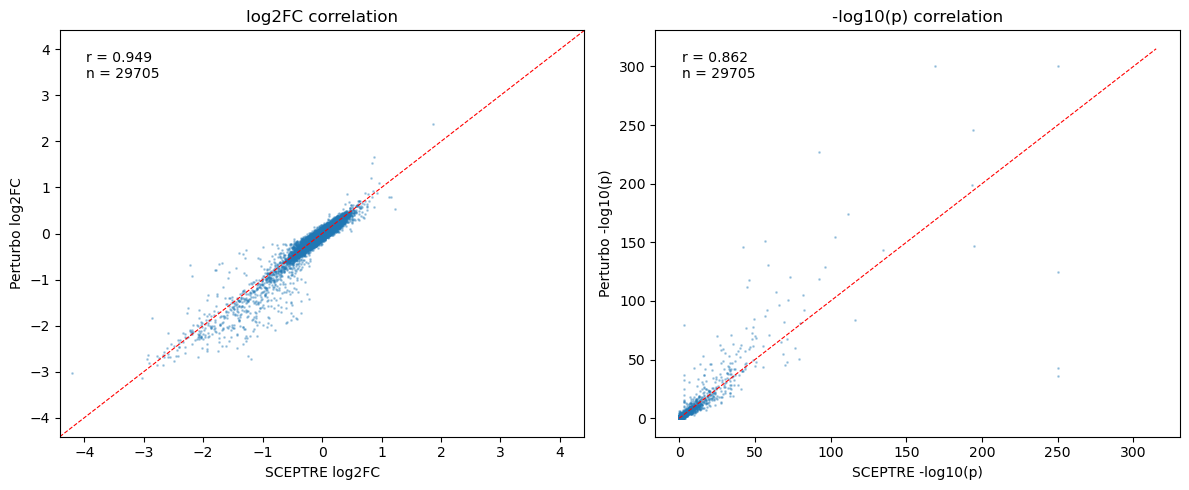

Dropped 2 rows with inf/NaN log2FC values


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
floor = 1e-300

# Clean rows with inf/NaN in either log2FC
mask = np.isfinite(cis["sceptre_log2_fc"]) & np.isfinite(cis["perturbo_log2_fc"])
cis_clean = cis[mask]

# log2FC correlation
axes[0].scatter(cis_clean["sceptre_log2_fc"], cis_clean["perturbo_log2_fc"], s=1, alpha=0.3)
lim = max(cis_clean["sceptre_log2_fc"].abs().max(), cis_clean["perturbo_log2_fc"].abs().max()) * 1.05
axes[0].plot([-lim, lim], [-lim, lim], "r--", lw=0.8)
axes[0].set(xlabel="SCEPTRE log2FC", ylabel="Perturbo log2FC", title="log2FC correlation")
axes[0].set_xlim(-lim, lim)
axes[0].set_ylim(-lim, lim)
r_fc = cis_clean["sceptre_log2_fc"].corr(cis_clean["perturbo_log2_fc"])
axes[0].text(0.05, 0.95, f"r = {r_fc:.3f}\nn = {len(cis_clean)}", transform=axes[0].transAxes, va="top", fontsize=10)

# -log10(p) correlation
s_pval = -np.log10(cis_clean["sceptre_p_value"].clip(lower=floor))
p_pval = -np.log10(cis_clean["perturbo_p_value"].clip(lower=floor))
axes[1].scatter(s_pval, p_pval, s=1, alpha=0.3)
lim2 = max(s_pval.max(), p_pval.max()) * 1.05
axes[1].plot([0, lim2], [0, lim2], "r--", lw=0.8)
axes[1].set(xlabel="SCEPTRE -log10(p)", ylabel="Perturbo -log10(p)", title="-log10(p) correlation")
r_pv = s_pval.corr(p_pval)
axes[1].text(0.05, 0.95, f"r = {r_pv:.3f}\nn = {len(cis_clean)}", transform=axes[1].transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.savefig("sceptre_vs_perturbo.png", dpi=150)
plt.show()

print(f"Dropped {len(cis) - len(cis_clean)} rows with inf/NaN log2FC values")

In [11]:
cis_clean = cis[np.isfinite(cis["sceptre_log2_fc"]) & np.isfinite(cis["perturbo_log2_fc"])].copy()
cis_clean["gene_symbol"] = cis_clean["gene_id"].map(id_to_symbol)
cis_clean["target_symbol"] = cis_clean["intended_target_name"].map(id_to_symbol)

floor = 1e-300
cis_clean["s_neglog10p"] = -np.log10(cis_clean["sceptre_p_value"].clip(lower=floor))
cis_clean["p_neglog10p"] = -np.log10(cis_clean["perturbo_p_value"].clip(lower=floor))

cis_clean["diff_log2fc"] = cis_clean["sceptre_log2_fc"] - cis_clean["perturbo_log2_fc"]
cis_clean["diff_neglog10p"] = cis_clean["s_neglog10p"] - cis_clean["p_neglog10p"]

cols = ["gene_symbol", "target_symbol", "sceptre_log2_fc", "perturbo_log2_fc"]

print("=== log2FC: SCEPTRE > Perturbo ===")
print(cis_clean.nlargest(5, "diff_log2fc")[cols + ["diff_log2fc"]].to_string(index=False))
print("\n=== log2FC: Perturbo > SCEPTRE ===")
print(cis_clean.nsmallest(5, "diff_log2fc")[cols + ["diff_log2fc"]].to_string(index=False))

cols_p = ["gene_symbol", "target_symbol", "s_neglog10p", "p_neglog10p"]

print("\n=== -log10(p): SCEPTRE > Perturbo ===")
print(cis_clean.nlargest(5, "diff_neglog10p")[cols_p + ["diff_neglog10p"]].to_string(index=False))
print("\n=== -log10(p): Perturbo > SCEPTRE ===")
print(cis_clean.nsmallest(5, "diff_neglog10p")[cols_p + ["diff_neglog10p"]].to_string(index=False))

=== log2FC: SCEPTRE > Perturbo ===
gene_symbol target_symbol  sceptre_log2_fc  perturbo_log2_fc  diff_log2fc
     ZNF718        ZNF718        -1.197493         -2.717032     1.519539
     ZNF292        ZNF292        -0.421924         -1.852335     1.430412
      ZFP14         ZFP14        -1.251701         -2.664603     1.412902
      BAZ2B         BAZ2B        -0.440970         -1.842749     1.401779
      HMGA1         HMGA1        -0.358406         -1.735121     1.376715

=== log2FC: Perturbo > SCEPTRE ===
gene_symbol target_symbol  sceptre_log2_fc  perturbo_log2_fc  diff_log2fc
      TRPM4          ATF5        -2.229587         -0.681832    -1.547755
       PRR3        POU5F1        -2.186340         -0.914463    -1.271877
      FOXJ2         FOXJ2        -4.201885         -3.028474    -1.173411
      TAF1A         TAF1A        -1.737209         -0.662246    -1.074963
      JOSD2          ATF5        -1.689193         -0.639769    -1.049424

=== -log10(p): SCEPTRE > Perturbo ===
ge

In [12]:
import os

# === THRESHOLDS ===
FDR_CUTOFF = 0.05
LOG2FC_CIS_MIN = 0.2
LOG2FC_TRANS_MIN = 1
REQUIRE_BOTH_METHODS = False
N_TOP_REGULATORS = 20

os.makedirs("cache", exist_ok=True)

In [13]:
# cis = mdata.uns["cis_per_element_results"].copy()
# cis["sceptre_fdr"] = multipletests(cis["sceptre_p_value"], method="fdr_bh")[1]
# cis["perturbo_fdr"] = multipletests(cis["perturbo_p_value"], method="fdr_bh")[1]
# cis["gene_symbol"] = cis["gene_id"].map(id_to_symbol)
# cis["target_symbol"] = cis["intended_target_name"].map(id_to_symbol)

# Method concordance
sceptre_n = (cis["sceptre_fdr"] < FDR_CUTOFF).sum()
perturbo_n = (cis["perturbo_fdr"] < FDR_CUTOFF).sum()
both_n = ((cis["sceptre_fdr"] < FDR_CUTOFF) & (cis["perturbo_fdr"] < FDR_CUTOFF)).sum()
direction_agree = (np.sign(cis["sceptre_log2_fc"]) == np.sign(cis["perturbo_log2_fc"])).mean()

print(f"SCEPTRE sig: {sceptre_n}, Perturbo sig: {perturbo_n}, Both: {both_n}")
print(f"Direction agreement: {direction_agree:.1%}")

# Filter
if REQUIRE_BOTH_METHODS:
    fdr_mask = (cis["sceptre_fdr"] < FDR_CUTOFF) & (cis["perturbo_fdr"] < FDR_CUTOFF)
else:
    fdr_mask = (cis["sceptre_fdr"] < FDR_CUTOFF) | (cis["perturbo_fdr"] < FDR_CUTOFF)

cis_sig = cis[
    fdr_mask
    & (np.sign(cis["sceptre_log2_fc"]) == np.sign(cis["perturbo_log2_fc"]))
    & (cis["sceptre_log2_fc"].abs() > LOG2FC_CIS_MIN)
].copy()

# Self-hits
cis["self_hit"] = cis["gene_id"] == cis["intended_target_name"]
self_hits = cis[cis["self_hit"]]
self_sig = (self_hits["sceptre_fdr"] < FDR_CUTOFF).sum()

print(f"\nCis significant: {len(cis_sig)} ({cis_sig['intended_target_name'].nunique()} elements, {cis_sig['gene_id'].nunique()} genes)")
print(f"Self-regulatory pairs: {len(self_hits)}, significant: {self_sig}")

print("\nTop cis hits:")
print(
    cis_sig.sort_values("sceptre_p_value")
    .head(15)[["gene_symbol", "target_symbol", "sceptre_log2_fc", "sceptre_fdr",
               "perturbo_log2_fc", "perturbo_fdr"]]
    .to_string(index=False)
)

SCEPTRE sig: 821, Perturbo sig: 853, Both: 723
Direction agreement: 86.8%

Cis significant: 818 (711 elements, 778 genes)
Self-regulatory pairs: 1097, significant: 621

Top cis hits:
gene_symbol target_symbol  sceptre_log2_fc   sceptre_fdr  perturbo_log2_fc  perturbo_fdr
    TP53BP1       TP53BP1        -1.508111 7.426750e-247         -2.023464  1.744785e-34
     ZBTB44        ZBTB44        -1.277337 7.426750e-247         -1.507059  2.612711e-41
    NGFRAP1       NGFRAP1        -2.387658 7.426750e-247         -2.312845  0.000000e+00
     ZNF644        ZNF644        -2.014950 7.426750e-247         -2.490157 3.114520e-122
       CNBP          CNBP        -1.297210 8.921913e-192         -2.068047 3.220192e-144
       CD81          CD81        -0.813194 4.345044e-191         -0.905283 2.099433e-242
       TFRC          TFRC        -2.660994 1.507897e-190         -2.583231 4.526705e-196
     MALAT1        MALAT1        -2.590971 4.400852e-166         -2.617509  0.000000e+00
      THEM4     

## 5. Trans results: FDR correction and filtering

FDR on ~22M rows is slow. We compute it once and cache to parquet.

In [14]:
import os

TRANS_PARQUET = f"cache/trans_sig_fdr{FDR_CUTOFF}.parquet"
if os.path.exists(TRANS_PARQUET):
    trans_sig = pd.read_parquet(TRANS_PARQUET)
    print(f"Loaded from cache: {len(trans_sig)} rows")
    if "fdr" not in trans_sig.columns:
        print("WARNING: cached file missing FDR column, recomputing from scratch...")
        os.remove(TRANS_PARQUET)

if not os.path.exists(TRANS_PARQUET):
    print("Computing trans FDR ...")
    trans = mdata.uns["trans_per_element_results"].copy()
    trans["fdr"] = multipletests(trans["p_value"], method="fdr_bh")[1]
    trans_sig = trans[
        (trans["fdr"] < FDR_CUTOFF)
        & (trans["log2_fc"].abs() > LOG2FC_TRANS_MIN)
        # & (trans["log2_fc_std"] < trans["log2_fc"].abs())  # effect > uncertainty
    ].copy()
    trans_sig.to_parquet(TRANS_PARQUET, index=False)
    print(f"Computed and saved: {len(trans_sig)} rows")

trans_sig["gene_symbol"] = trans_sig["gene_id"].map(id_to_symbol)
trans_sig["target_symbol"] = trans_sig["intended_target_name"].map(id_to_symbol)

print(f"\nTrans significant: {len(trans_sig)} ({trans_sig['intended_target_name'].nunique()} elements, {trans_sig['gene_id'].nunique()} genes)")

Loaded from cache: 2871 rows

Trans significant: 2871 (537 elements, 1642 genes)


## 6. P-value and log2FC distributions

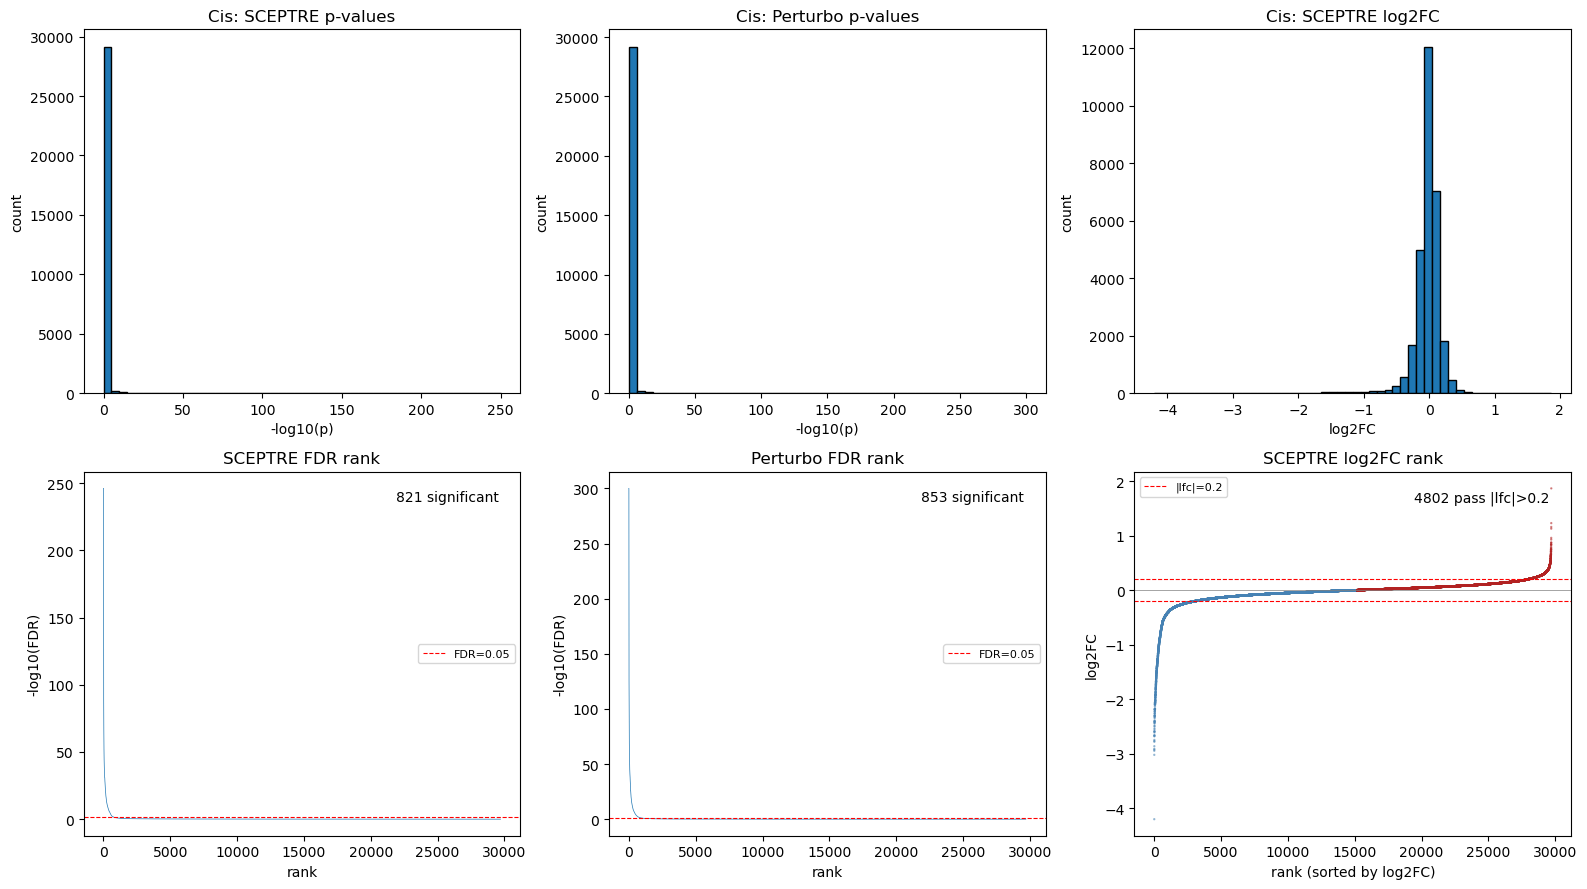


Cis significant: 818 (711 elements, 778 genes)


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
floor = 1e-300

# --- Top row: distributions ---
axes[0, 0].hist(-np.log10(cis["sceptre_p_value"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0, 0].set(xlabel="-log10(p)", ylabel="count", title="Cis: SCEPTRE p-values")

axes[0, 1].hist(-np.log10(cis["perturbo_p_value"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0, 1].set(xlabel="-log10(p)", ylabel="count", title="Cis: Perturbo p-values")

axes[0, 2].hist(cis["sceptre_log2_fc"][np.isfinite(cis["sceptre_log2_fc"])], bins=50, edgecolor="black")
axes[0, 2].set(xlabel="log2FC", ylabel="count", title="Cis: SCEPTRE log2FC")

# --- Bottom row: rank plots ---
# SCEPTRE FDR rank plot
sceptre_fdr_sorted = np.sort(cis["sceptre_fdr"].values)
axes[1, 0].plot(np.arange(1, len(sceptre_fdr_sorted) + 1), -np.log10(sceptre_fdr_sorted.clip(min=floor)), lw=0.5)
axes[1, 0].axhline(-np.log10(FDR_CUTOFF), color="r", ls="--", lw=0.8, label=f"FDR={FDR_CUTOFF}")
n_sig_s = (sceptre_fdr_sorted < FDR_CUTOFF).sum()
axes[1, 0].text(0.95, 0.95, f"{n_sig_s} significant", transform=axes[1, 0].transAxes, ha="right", va="top")
axes[1, 0].set(xlabel="rank", ylabel="-log10(FDR)", title="SCEPTRE FDR rank")
axes[1, 0].legend(fontsize=8)

# Perturbo FDR rank plot
perturbo_fdr_sorted = np.sort(cis["perturbo_fdr"].values)
axes[1, 1].plot(np.arange(1, len(perturbo_fdr_sorted) + 1), -np.log10(perturbo_fdr_sorted.clip(min=floor)), lw=0.5)
axes[1, 1].axhline(-np.log10(FDR_CUTOFF), color="r", ls="--", lw=0.8, label=f"FDR={FDR_CUTOFF}")
n_sig_p = (perturbo_fdr_sorted < FDR_CUTOFF).sum()
axes[1, 1].text(0.95, 0.95, f"{n_sig_p} significant", transform=axes[1, 1].transAxes, ha="right", va="top")
axes[1, 1].set(xlabel="rank", ylabel="-log10(FDR)", title="Perturbo FDR rank")
axes[1, 1].legend(fontsize=8)

# log2FC rank plot (sorted by absolute value, colored by sign)
lfc_sorted = cis["sceptre_log2_fc"].dropna().sort_values()
ranks = np.arange(1, len(lfc_sorted) + 1)
colors = np.where(lfc_sorted.values < 0, "steelblue", "firebrick")
axes[1, 2].scatter(ranks, lfc_sorted.values, s=0.5, c=colors, alpha=0.5)
axes[1, 2].axhline(LOG2FC_CIS_MIN, color="r", ls="--", lw=0.8, label=f"|lfc|={LOG2FC_CIS_MIN}")
axes[1, 2].axhline(-LOG2FC_CIS_MIN, color="r", ls="--", lw=0.8)
axes[1, 2].axhline(0, color="gray", ls="-", lw=0.5)
n_pass_lfc = (lfc_sorted.abs() > LOG2FC_CIS_MIN).sum()
axes[1, 2].text(0.95, 0.95, f"{n_pass_lfc} pass |lfc|>{LOG2FC_CIS_MIN}", transform=axes[1, 2].transAxes, ha="right", va="top")
axes[1, 2].set(xlabel="rank (sorted by log2FC)", ylabel="log2FC", title="SCEPTRE log2FC rank")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("cis_distributions.png", dpi=150)
plt.show()

print(f"\nCis significant: {len(cis_sig)} ({cis_sig['intended_target_name'].nunique()} elements, {cis_sig['gene_id'].nunique()} genes)")

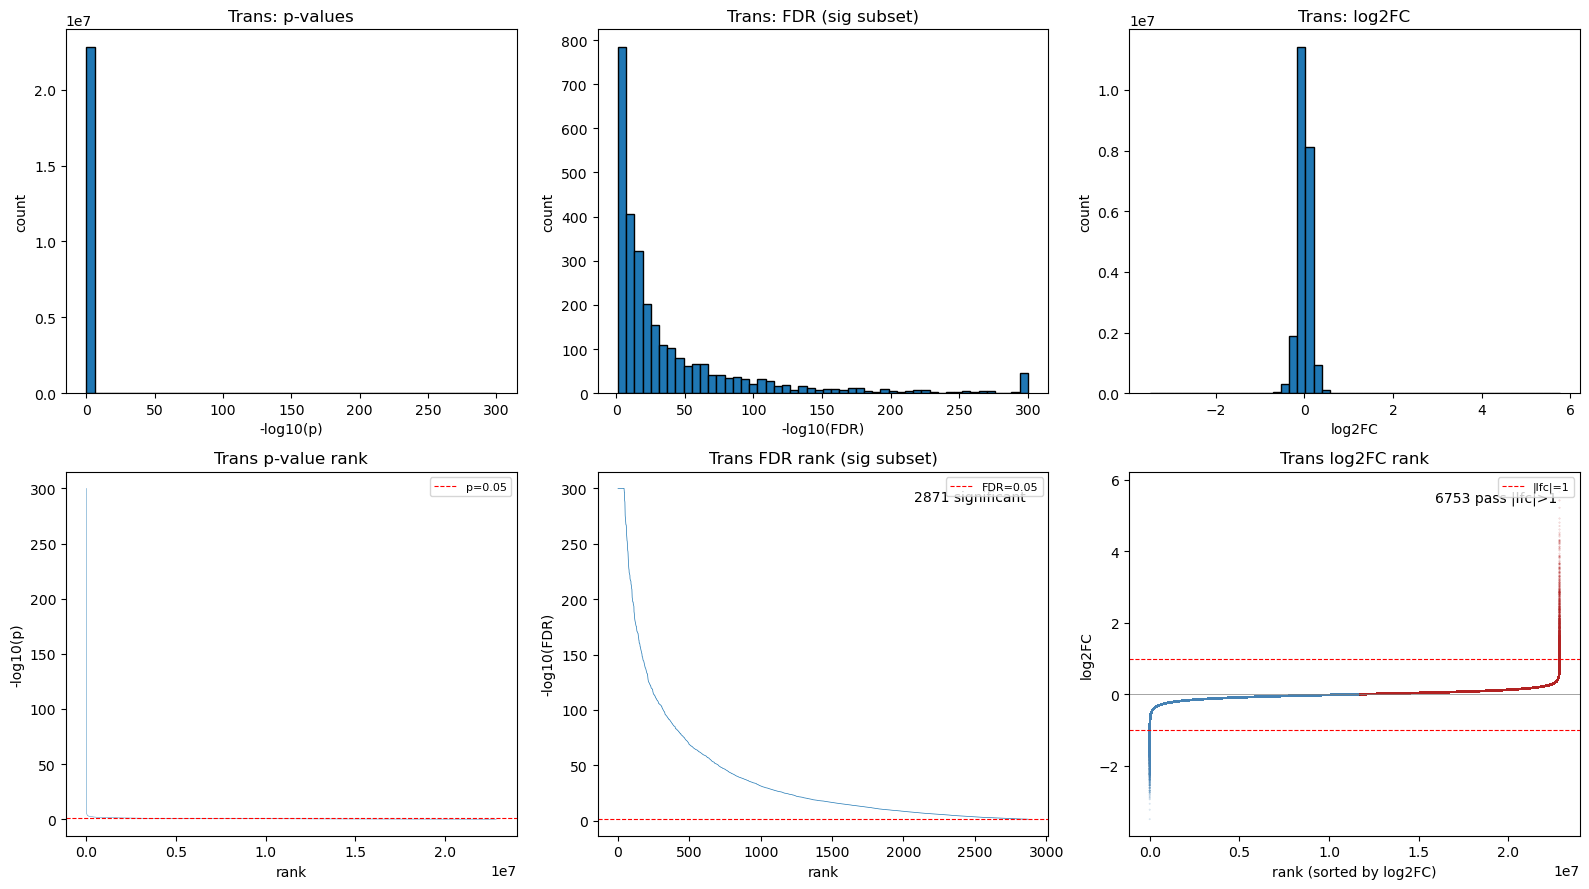

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
floor = 1e-300

# Use full trans if available, otherwise load from mdata
if "trans" not in dir():
    trans = mdata.uns["trans_per_element_results"]

# --- Top row: distributions ---
axes[0, 0].hist(-np.log10(trans["p_value"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0, 0].set(xlabel="-log10(p)", ylabel="count", title="Trans: p-values")

trans_fdr_vals = trans_sig["fdr"] if "fdr" in trans_sig.columns else None
if trans_fdr_vals is not None:
    axes[0, 1].hist(-np.log10(trans_fdr_vals.clip(lower=floor)), bins=50, edgecolor="black")
    axes[0, 1].set(xlabel="-log10(FDR)", ylabel="count", title="Trans: FDR (sig subset)")
else:
    axes[0, 1].text(0.5, 0.5, "FDR not available", transform=axes[0, 1].transAxes, ha="center")

lfc_finite = trans["log2_fc"][np.isfinite(trans["log2_fc"])]
axes[0, 2].hist(lfc_finite, bins=50, edgecolor="black")
axes[0, 2].set(xlabel="log2FC", ylabel="count", title="Trans: log2FC")

# --- Bottom row: rank plots ---
# p-value rank
pval_sorted = np.sort(trans["p_value"].values)
ranks_p = np.arange(1, len(pval_sorted) + 1)
axes[1, 0].plot(ranks_p, -np.log10(pval_sorted.clip(min=floor)), lw=0.3)
axes[1, 0].axhline(-np.log10(0.05), color="r", ls="--", lw=0.8, label="p=0.05")
axes[1, 0].set(xlabel="rank", ylabel="-log10(p)", title="Trans p-value rank")
axes[1, 0].legend(fontsize=8, loc="upper right")

# FDR rank (on sig subset)
if trans_fdr_vals is not None:
    fdr_sorted = np.sort(trans_fdr_vals.values)
    axes[1, 1].plot(np.arange(1, len(fdr_sorted) + 1), -np.log10(fdr_sorted.clip(min=floor)), lw=0.5)
    axes[1, 1].axhline(-np.log10(FDR_CUTOFF), color="r", ls="--", lw=0.8, label=f"FDR={FDR_CUTOFF}")
    axes[1, 1].text(0.95, 0.95, f"{len(trans_sig)} significant", transform=axes[1, 1].transAxes, ha="right", va="top")
    axes[1, 1].set(xlabel="rank", ylabel="-log10(FDR)", title="Trans FDR rank (sig subset)")
    axes[1, 1].legend(fontsize=8, loc="upper right")

# log2FC rank
lfc_sorted = trans["log2_fc"].dropna()
lfc_sorted = lfc_sorted[np.isfinite(lfc_sorted)].sort_values()
ranks_l = np.arange(1, len(lfc_sorted) + 1)
colors = np.where(lfc_sorted.values < 0, "steelblue", "firebrick")
axes[1, 2].scatter(ranks_l, lfc_sorted.values, s=0.1, c=colors, alpha=0.3)
axes[1, 2].axhline(LOG2FC_TRANS_MIN, color="r", ls="--", lw=0.8, label=f"|lfc|={LOG2FC_TRANS_MIN}")
axes[1, 2].axhline(-LOG2FC_TRANS_MIN, color="r", ls="--", lw=0.8)
axes[1, 2].axhline(0, color="gray", ls="-", lw=0.5)
n_pass = (lfc_sorted.abs() > LOG2FC_TRANS_MIN).sum()
axes[1, 2].text(0.95, 0.95, f"{n_pass} pass |lfc|>{LOG2FC_TRANS_MIN}", transform=axes[1, 2].transAxes, ha="right", va="top")
axes[1, 2].set(xlabel="rank (sorted by log2FC)", ylabel="log2FC", title="Trans log2FC rank")
axes[1, 2].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("trans_distributions.png", dpi=150)
plt.show()

## 7. Top trans regulators and their downstream targets

In [16]:
N_TOP_REGULATORS = 50
N_TOP_TARGETS = 10

# Rank elements by number of trans targets
targeting_elements = set(
    guide_var[guide_var["targeting"] == True]["intended_target_name"].unique()
)

top_trans_elements = (
    trans_sig[trans_sig["intended_target_name"].isin(targeting_elements)]
    .groupby("intended_target_name").size()
    .sort_values(ascending=False)
    .head(N_TOP_REGULATORS)
)

# Build symbol <-> ensembl lookup for top regulators
top_regulators = [id_to_symbol.get(e, e) for e in top_trans_elements.index]
regulator_ens = dict(zip(top_regulators, top_trans_elements.index))
ens_to_regulator = {v: k for k, v in regulator_ens.items()}

print("Top trans regulators:")
for ens_id, count in top_trans_elements.items():
    print(f"  {id_to_symbol.get(ens_id, ens_id)} ({ens_id}): {count} trans targets")

# Show top up/down targets for leading regulators
for ens_id in top_trans_elements.index[:12]:
    symbol = id_to_symbol.get(ens_id, ens_id)
    subset = trans_sig[trans_sig["intended_target_name"] == ens_id].copy()
    subset["target_symbol"] = subset["gene_id"].map(id_to_symbol)

    up = subset[subset["log2_fc"] > 0].nlargest(N_TOP_TARGETS, "log2_fc")
    down = subset[subset["log2_fc"] < 0].nsmallest(N_TOP_TARGETS, "log2_fc")

    print(f"\n--- {symbol}: {len(subset)} trans targets ---")
    print("  Upregulated:")
    for _, r in up.iterrows():
        print(f"    {r['target_symbol']}: log2FC = {r['log2_fc']:.2f}")
    print("  Downregulated:")
    for _, r in down.iterrows():
        print(f"    {r['target_symbol']}: log2FC = {r['log2_fc']:.2f}")

Top trans regulators:
  FOXH1 (ENSG00000160973): 733 trans targets
  SOX17 (ENSG00000164736): 628 trans targets
  SETDB1 (ENSG00000143379): 180 trans targets
  DBX1 (ENSG00000109851): 130 trans targets
  ZC3H3 (ENSG00000014164): 91 trans targets
  DNMT1 (ENSG00000130816): 53 trans targets
  RCOR2 (ENSG00000167771): 45 trans targets
  SNAI1 (ENSG00000124216): 38 trans targets
  HNF1B (ENSG00000275410): 36 trans targets
  FOXA2 (ENSG00000125798): 32 trans targets
  POGK (ENSG00000143157): 23 trans targets
  SMAD4 (ENSG00000141646): 17 trans targets
  SMARCC1 (ENSG00000173473): 15 trans targets
  ADNP2 (ENSG00000101544): 15 trans targets
  ZNF532 (ENSG00000074657): 13 trans targets
  ZNF90 (ENSG00000213988): 12 trans targets
  ZNF644 (ENSG00000122482): 12 trans targets
  PCGF6 (ENSG00000156374): 11 trans targets
  CHAMP1 (ENSG00000198824): 9 trans targets
  GATAD1 (ENSG00000157259): 9 trans targets
  MBD1 (ENSG00000141644): 9 trans targets
  ZNF649 (ENSG00000198093): 8 trans targets
  GAT

## 8. Cis self-knockdown efficiency for top regulators

In [17]:
top_ens_set = set(regulator_ens.values())

cis_top = cis[
    (cis["intended_target_name"].isin(top_ens_set))
    & (cis["gene_id"].isin(top_ens_set))
].copy()
cis_top["target_symbol"] = cis_top["intended_target_name"].map(id_to_symbol)
cis_top["gene_symbol"] = cis_top["gene_id"].map(id_to_symbol)

print("Cis effects for top regulators (self-hits):")
print(
    cis_top[["gene_symbol", "target_symbol", "sceptre_log2_fc", "sceptre_fdr",
             "perturbo_log2_fc", "perturbo_fdr"]]
    .sort_values("sceptre_fdr")
    .to_string(index=False)
)

Cis effects for top regulators (self-hits):
gene_symbol target_symbol  sceptre_log2_fc   sceptre_fdr  perturbo_log2_fc  perturbo_fdr
     ZNF644        ZNF644        -2.014950 7.426750e-247         -2.490157 3.114520e-122
       CNBP          CNBP        -1.297210 8.921913e-192         -2.068047 3.220192e-144
    SMARCC1       SMARCC1        -0.475717 1.718010e-113         -1.182432  1.154677e-81
      SOX17         SOX17        -1.277774 3.324526e-100         -2.216733 6.746635e-152
     ZNF532        ZNF532        -1.276427  1.186804e-89         -1.694639 5.619926e-224
      ZNF90         ZNF90        -2.063567  4.882579e-57         -2.193387  8.435683e-69
     SETDB1        SETDB1        -1.436984  1.063602e-34         -1.770347  3.641718e-35
     HMGXB3        HMGXB3        -1.672662  8.939625e-32         -2.071281  5.646799e-20
       KLF8          KLF8        -1.777521  4.276274e-31         -2.145620  6.976094e-51
        DR1           DR1        -0.945551  1.588497e-29         -

In [19]:
print(f"Number of top regulators: {len(top_regulators)}")
print(f"Number of regulator_ens entries: {len(regulator_ens)}")

# Check for None/NaN symbols
for sym, ens in regulator_ens.items():
    if sym is None or pd.isna(sym) or ens is None or pd.isna(ens):
        print(f"BAD ENTRY: symbol={sym}, ensembl={ens}")

# Check which Ensembl IDs map to None symbols
for ens_id in top_trans_elements.index[:N_TOP_REGULATORS]:
    sym = id_to_symbol.get(ens_id, None)
    print(f"  {ens_id} -> {sym}")

Number of top regulators: 50
Number of regulator_ens entries: 50
  ENSG00000160973 -> FOXH1
  ENSG00000164736 -> SOX17
  ENSG00000143379 -> SETDB1
  ENSG00000109851 -> DBX1
  ENSG00000014164 -> ZC3H3
  ENSG00000130816 -> DNMT1
  ENSG00000167771 -> RCOR2
  ENSG00000124216 -> SNAI1
  ENSG00000275410 -> HNF1B
  ENSG00000125798 -> FOXA2
  ENSG00000143157 -> POGK
  ENSG00000141646 -> SMAD4
  ENSG00000173473 -> SMARCC1
  ENSG00000101544 -> ADNP2
  ENSG00000074657 -> ZNF532
  ENSG00000213988 -> ZNF90
  ENSG00000122482 -> ZNF644
  ENSG00000156374 -> PCGF6
  ENSG00000198824 -> CHAMP1
  ENSG00000157259 -> GATAD1
  ENSG00000141644 -> MBD1
  ENSG00000198093 -> ZNF649
  ENSG00000136574 -> GATA4
  ENSG00000205189 -> ZBTB10
  ENSG00000135111 -> TBX3
  ENSG00000185155 -> MIXL1
  ENSG00000113716 -> HMGXB3
  ENSG00000178691 -> SUZ12
  ENSG00000102349 -> KLF8
  ENSG00000077463 -> SIRT6
  ENSG00000162702 -> ZNF281
  ENSG00000176887 -> SOX11
  ENSG00000137871 -> ZNF280D
  ENSG00000204366 -> ZBTB12
  ENSG00

## 9. Save filtered results

In [20]:
cis_sig.to_parquet(f"cache/cis_sig_fdr{FDR_CUTOFF}_lfc{LOG2FC_CIS_MIN}_both{REQUIRE_BOTH_METHODS}.parquet", index=False)
trans_sig.to_parquet(f"cache/trans_sig_fdr{FDR_CUTOFF}_lfc{LOG2FC_TRANS_MIN}.parquet", index=False)

print(f"cis_sig.parquet: {len(cis_sig)} rows")
print(f"trans_sig.parquet: {len(trans_sig)} rows")
print(f"cache/cis_sig_fdr{FDR_CUTOFF}_lfc{LOG2FC_CIS_MIN}_both{REQUIRE_BOTH_METHODS}.parquet: {len(cis_sig)} rows")
print(f"cache/cross_talk_fdr{FDR_CUTOFF}_top{N_TOP_REGULATORS}.csv: {cross_talk.shape}")

cis_sig.parquet: 818 rows
trans_sig.parquet: 2871 rows
cache/cis_sig_fdr0.05_lfc0.2_bothFalse.parquet: 818 rows
cache/cross_talk_fdr0.05_top50.csv: (50, 50)


## 10. Disease & GWAS (WG3)

Goals:
1. Which TFs regulate disease/GWAS genes in this lineage
2. For TFs active in multiple lineages, is their activity convergent or divergent
3. Annotate GWAS variants near important TFs or upstream of their downstream targets

*To be developed.*

In [21]:
gwas = pd.read_csv("data/gwas-catalog-download-associations-v1.0-full.tsv", sep="\t", low_memory=False)
print(f"Shape: {gwas.shape}")
print(f"Unique traits: {gwas['DISEASE/TRAIT'].nunique()}")
print(f"Rows with Ensembl gene IDs: {gwas['SNP_GENE_IDS'].notna().sum()}")
print(f"Unique mapped genes: {gwas['MAPPED_GENE'].nunique()}")

# Check how many of your trans target genes appear in GWAS
gwas_ensembl = set(gwas["SNP_GENE_IDS"].dropna().str.split(", ").explode().unique())
trans_genes = set(trans_sig["gene_id"].unique())
overlap = trans_genes & gwas_ensembl
print(f"\nTrans target genes in GWAS catalog: {len(overlap)} / {len(trans_genes)}")

Shape: (1099366, 34)
Unique traits: 50278
Rows with Ensembl gene IDs: 638633
Unique mapped genes: 47212

Trans target genes in GWAS catalog: 1431 / 1642


In [79]:
print(gwas["DISEASE/TRAIT"].value_counts().head(10))

DISEASE/TRAIT
Height                                                             26197
Body mass index                                                    14023
Height (baseline)                                                   6906
Type 2 diabetes                                                     6571
Systolic blood pressure                                             6419
Bone mineral density mean                                           5309
Electrocardiogram morphology (amplitude at temporal datapoints)     5261
Educational attainment                                              5256
Platelet count                                                      4886
Diastolic blood pressure                                            4871
Name: count, dtype: int64


In [ ]:
gwas = pd.read_csv("data/gwas-catalog-download-associations-v1.0-full.tsv", sep="\t", low_memory=False)

# Clean up: keep rows with valid chromosome and position
gwas = gwas[gwas["CHR_POS"].notna() & gwas["CHR_ID"].notna()].copy()
gwas["CHR_POS"] = pd.to_numeric(gwas["CHR_POS"], errors="coerce")
gwas = gwas[gwas["CHR_POS"].notna()].copy()
gwas["CHR_ID"] = gwas["CHR_ID"].astype(str)

print(f"GWAS catalog: {len(gwas)} associations, {gwas['DISEASE/TRAIT'].nunique()} traits")

# Build gene coordinate lookup from gene_var
gene_coords = gene_var[["symbol", "gene_chr", "gene_start", "gene_end"]].copy()
gene_coords = gene_coords[gene_coords["gene_chr"].notna()]
gene_coords["chr_clean"] = gene_coords["gene_chr"].str.replace("chr", "")

# Also get TF element coordinates from trans_sig
element_coords = (
    trans_sig[["intended_target_name", "intended_target_chr",
               "intended_target_start", "intended_target_end"]]
    .drop_duplicates("intended_target_name")
    .copy()
)
element_coords["chr_clean"] = element_coords["intended_target_chr"].str.replace("chr", "")
element_coords["target_symbol"] = element_coords["intended_target_name"].map(id_to_symbol)

WINDOW = 50_000  # 50kb window around each feature

# --- 1. GWAS SNPs near perturbed TF elements ---
tf_gwas_hits = []
for _, el in element_coords.iterrows():
    nearby = gwas[
        (gwas["CHR_ID"] == el["chr_clean"])
        & (gwas["CHR_POS"] >= el["intended_target_start"] - WINDOW)
        & (gwas["CHR_POS"] <= el["intended_target_end"] + WINDOW)
    ]
    for _, snp in nearby.iterrows():
        tf_gwas_hits.append({
            "tf_ensembl": el["intended_target_name"],
            "tf_symbol": el["target_symbol"],
            "snp": snp["SNPS"],
            "trait": snp["DISEASE/TRAIT"],
            "pvalue": snp["P-VALUE"],
            "distance": min(
                abs(snp["CHR_POS"] - el["intended_target_start"]),
                abs(snp["CHR_POS"] - el["intended_target_end"])
            ),
            "mapped_gene": snp["MAPPED_GENE"],
        })

tf_gwas = pd.DataFrame(tf_gwas_hits)
print(f"\n=== GWAS SNPs within {WINDOW//1000}kb of perturbed TF elements ===")
print(f"Total hits: {len(tf_gwas)}")
print(f"TFs with nearby GWAS SNPs: {tf_gwas['tf_symbol'].nunique()}")
print(f"Unique traits: {tf_gwas['trait'].nunique()}")

# --- 2. GWAS SNPs near downstream target genes ---
target_genes = trans_sig["gene_id"].unique()
target_coords = gene_coords[gene_coords.index.isin(target_genes)]

gene_gwas_hits = []
for ens_id, gc in target_coords.iterrows():
    nearby = gwas[
        (gwas["CHR_ID"] == gc["chr_clean"])
        & (gwas["CHR_POS"] >= gc["gene_start"] - WINDOW)
        & (gwas["CHR_POS"] <= gc["gene_end"] + WINDOW)
    ]
    for _, snp in nearby.iterrows():
        gene_gwas_hits.append({
            "gene_ensembl": ens_id,
            "gene_symbol": gc["symbol"],
            "snp": snp["SNPS"],
            "trait": snp["DISEASE/TRAIT"],
            "pvalue": snp["P-VALUE"],
            "distance": min(
                abs(snp["CHR_POS"] - gc["gene_start"]),
                abs(snp["CHR_POS"] - gc["gene_end"])
            ),
            "mapped_gene": snp["MAPPED_GENE"],
        })

gene_gwas = pd.DataFrame(gene_gwas_hits)
print(f"\n=== GWAS SNPs within {WINDOW//1000}kb of trans target genes ===")
print(f"Total hits: {len(gene_gwas)}")
print(f"Genes with nearby GWAS SNPs: {gene_gwas['gene_symbol'].nunique()}")
print(f"Unique traits: {gene_gwas['trait'].nunique()}")

# Top traits near TFs
print(f"\nTop traits near TF elements:")
print(tf_gwas["trait"].value_counts().head(15).to_string())

# Top traits near target genes
print(f"\nTop traits near target genes:")
print(gene_gwas["trait"].value_counts().head(15).to_string())

GWAS catalog: 919591 associations, 41913 traits

=== GWAS SNPs within 50kb of perturbed TF elements ===
Total hits: 31568
TFs with nearby GWAS SNPs: 525
Unique traits: 5776

=== GWAS SNPs within 50kb of trans target genes ===
Total hits: 177624
Genes with nearby GWAS SNPs: 1628
Unique traits: 17696

Top traits near TF elements:
trait
Height                                                             1196
Type 2 diabetes                                                     359
Body mass index                                                     343
Height (baseline)                                                   285
Sex hormone-binding globulin levels                                 251
Triglyceride levels                                                 217
Electrocardiogram morphology (amplitude at temporal datapoints)     213
Systolic blood pressure                                             211
Waist-to-hip ratio adjusted for BMI                                 210
Waist circumfere

In [88]:
from scipy.stats import fisher_exact

# Count how many GWAS entries each trait has in the full catalog
trait_counts = gwas["DISEASE/TRAIT"].value_counts()
total_snps = len(gwas)

def trait_enrichment(gwas_hits_df, label, min_hits=5):
    hit_traits = gwas_hits_df["trait"].value_counts()
    hit_traits = hit_traits[hit_traits >= min_hits]
    
    n_hits = len(gwas_hits_df)
    results = []
    for trait, observed in hit_traits.items():
        catalog_n = trait_counts.get(trait, 1)
        expected = catalog_n * (n_hits / total_snps)
        
        # Fisher exact test
        a = observed
        b = max(catalog_n - observed, 0)
        c = max(n_hits - observed, 0)
        d = max(total_snps - catalog_n - c, 0)
        odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
        
        results.append({
            "trait": trait,
            "observed": observed,
            "catalog_total": catalog_n,
            "expected": round(expected, 2),
            "enrichment": round(observed / max(expected, 0.01), 2),
            "odds_ratio": round(odds_ratio, 2),
            "pvalue": pval,
        })
    
    edf = pd.DataFrame(results)
    edf["fdr"] = multipletests(edf["pvalue"], method="fdr_bh")[1]
    edf = edf.sort_values("fdr")
    
    print(f"\n=== {label}: trait enrichment (>={min_hits} hits) ===")
    print(edf.head(20).to_string(index=False))
    return edf

tf_enrichment = trait_enrichment(tf_gwas, "Near TF elements")
gene_enrichment = trait_enrichment(gene_gwas, "Near target genes")


=== Near TF elements: trait enrichment (>=5 hits) ===
                                                   trait  observed  catalog_total  expected  enrichment  odds_ratio       pvalue          fdr
                     Sex hormone-binding globulin levels       251           3219    110.50        2.27        2.39 4.985732e-32 5.763506e-29
                       Small VLDL particle concentration        17             17      0.58       29.13         inf 1.271402e-25 3.674352e-23
                  Very large VLDL particle concentration        17             17      0.58       29.13         inf 1.271402e-25 3.674352e-23
                      Medium VLDL particle concentration        17             17      0.58       29.13         inf 1.271402e-25 3.674352e-23
                 Total cholesterol levels in medium VLDL        16             17      0.58       27.42      450.32 6.095873e-23 1.409366e-20
                                                  Height      1196          26197    899.30  

In [ ]:
tf_enrichment.loc[tf_enrichment["trait"].str.contains("diabetes", case=False), :]
gene_enrichment.loc[gene_enrichment["trait"].str.contains("diabetes", case=False), :]